# 任务二：Boston Housing 数据集回归任务实践

这个 notebook 用来完成实验题中的回归任务。

整体流程如下：

1. 导入库并准备数据加载函数。
2. 加载 Boston Housing 数据，查看特征信息和目标变量分布。
3. 按 7:3 划分训练集和测试集，并进行标准化。
4. 训练 3 个回归模型并计算误差指标。
5. 用图表比较不同模型的表现。
6. 绘制“预测值 vs 真实值”散点图，直观观察拟合效果。

说明：新版 `scikit-learn` 已移除 `load_boston()`，
所以这里优先读取 `sklearn` 安装包中自带的 `boston_house_prices.csv`。

## 第 1 步：导入库并定义辅助函数

这一格会完成两个准备工作：

- 定义标准化函数；
- 定义兼容版 Boston 数据加载函数。

这样后面的代码会更清晰，也更容易在不同环境里运行。

In [1]:
# 忽略不影响实验核心结论的警告信息
import warnings
warnings.filterwarnings("ignore")

# 导入数值计算、表格处理和绘图库
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# files 用来读取 sklearn 安装目录中的内置 CSV 文件
from importlib.resources import files
from IPython.display import display

# 导入数据划分、回归模型和评估指标
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 设置绘图风格和中文字体
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 固定随机种子，保证结果稳定
RANDOM_STATE = 42


def manual_standardize(train_df, test_df):
    """
    按实验题要求手动标准化。

    只用训练集统计量，是为了避免测试集信息泄露。
    """
    mean = train_df.mean()
    std = train_df.std(ddof=0).replace(0, 1)
    train_scaled = (train_df - mean) / std
    test_scaled = (test_df - mean) / std
    return train_scaled, test_scaled, mean, std


def load_boston_compatible():
    """
    优先读取 sklearn 安装目录中的 boston_house_prices.csv。

    如果当前环境中确实读不到 Boston 数据，
    就回退到 diabetes 数据集，保证 notebook 至少能运行。
    """
    try:
        path = files("sklearn.datasets.data").joinpath("boston_house_prices.csv")
        raw = pd.read_csv(path, skiprows=1)
        X = raw.drop(columns=["MEDV"])
        y = raw["MEDV"]
        source = f"Boston Housing (sklearn 内置 CSV): {path}"
        return X, y, source
    except Exception as exc:
        from sklearn.datasets import load_diabetes

        dataset = load_diabetes(as_frame=True)
        X = dataset.data.copy()
        y = pd.Series(dataset.target, name="target")
        source = f"Boston 数据加载失败，已回退到 diabetes 数据集。原因：{exc}"
        return X, y, source

## 第 2 步：加载数据并完成初步探索

这一格主要回答几个问题：

- 数据一共有多少个样本、多少个特征？
- 每个特征代表什么含义？
- 特征的大致取值范围是什么？
- 房价目标变量的分布是否偏态，是否集中在某个区间？

In [2]:
# 加载数据
X, y, data_source = load_boston_compatible()

# 方便在报告里解释各个特征含义
boston_feature_desc = {
    "CRIM": "城镇人均犯罪率",
    "ZN": "住宅用地超过 25000 平方英尺的比例",
    "INDUS": "城镇非零售商业用地比例",
    "CHAS": "是否邻近查尔斯河（1 是，0 否）",
    "NOX": "一氧化氮浓度",
    "RM": "每套住宅的平均房间数",
    "AGE": "1940 年前建成的自住房比例",
    "DIS": "到五个波士顿就业中心的加权距离",
    "RAD": "公路可达性指数",
    "TAX": "每 10000 美元的房产税率",
    "PTRATIO": "城镇师生比",
    "B": "与黑人比例相关的统计量",
    "LSTAT": "低收入人口比例",
    "MEDV": "自住房屋价格中位数（目标变量）",
}

# 先打印数据来源，方便你确认当前到底是在用 Boston 还是回退数据
print(data_source)

print("\n数据规模：", X.shape)
print("特征列：", list(X.columns))

print("\n前 5 行数据：")
display(X.head())

print("\n描述性统计：")
display(X.describe())

# 如果当前数据集列名确实和 Boston 一致，就把中文说明表展示出来
if set(X.columns).issubset(set(boston_feature_desc)):
    feature_desc_df = pd.DataFrame(
        {"Feature": list(X.columns), "Description": [boston_feature_desc[col] for col in X.columns]}
    )
    print("\n特征说明：")
    display(feature_desc_df)

Boston Housing (sklearn 内置 CSV): d:\kaifagongju\Anaconda\envs\DL\lib\site-packages\sklearn\datasets\data\boston_house_prices.csv

数据规模： (506, 13)
特征列： ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

前 5 行数据：


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33



描述性统计：


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000



特征说明：


,Feature,Description
0,CRIM,城镇人均犯罪率
1,ZN,住宅用地超过 25000 平方英尺的比例
2,INDUS,城镇非零售商业用地比例
3,CHAS,是否邻近查尔斯河（1 是，0 否）
4,NOX,一氧化氮浓度
5,RM,每套住宅的平均房间数
6,AGE,1940 年前建成的自住房比例
7,DIS,到五个波士顿就业中心的加权距离
8,RAD,公路可达性指数
9,TAX,每 10000 美元的房产税率


## 第 3 步：观察目标变量分布

回归任务里，目标变量的分布非常重要。

通过这张图，我们可以观察：

- 房价是否集中在某个区间；
- 分布是否偏斜；
- 是否存在长尾现象。

这些信息会影响模型拟合的难度和误差表现。

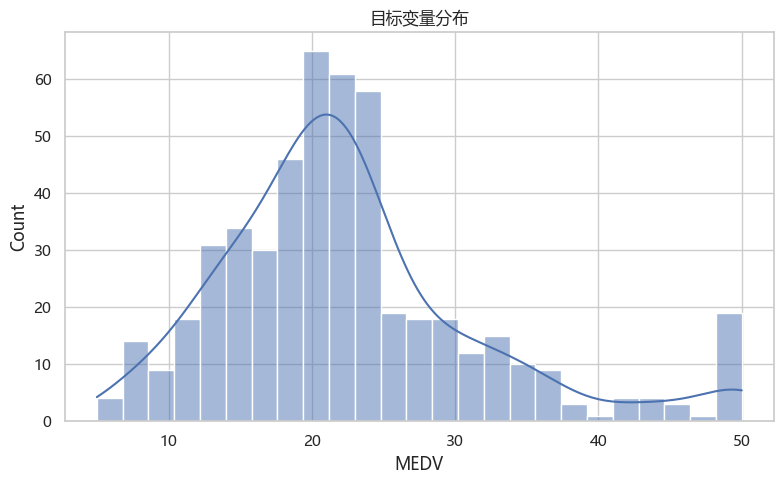

In [3]:
# 使用直方图 + KDE 曲线观察目标变量分布形态
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=25, kde=True)
plt.title("目标变量分布")
plt.xlabel(y.name if y.name is not None else "Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 第 4 步：划分训练集 / 测试集，并进行标准化

这里继续遵循标准机器学习流程：

- 训练集用来训练模型；
- 测试集用来检验模型泛化能力；
- 按题目要求对特征做标准化。

注意：树模型其实并不依赖标准化，但为了统一流程、满足实验要求，
我们依然对三个模型使用同一份标准化数据。

In [4]:
# 按 7:3 随机划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

# 用训练集统计量对训练集和测试集同时进行标准化
X_train_scaled, X_test_scaled, train_mean, train_std = manual_standardize(X_train, X_test)

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (354, 13)
测试集大小： (152, 13)


## 第 5 步：训练回归模型并计算评估指标

本任务要求比较以下 3 个模型：

- LinearRegression
- DecisionTreeRegressor
- RandomForestRegressor

对每个模型，我们在测试集上计算：

- MSE：均方误差，越小越好；
- MAE：平均绝对误差，越小越好；
- R²：决定系数，越接近 1 越好。

In [5]:
# 按题目要求构造 3 个回归模型
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForestRegressor": RandomForestRegressor(random_state=RANDOM_STATE),
}

# 用于存放每个模型的评估结果
results = []

# 保存每个模型的预测值，后面画散点图时会用到
predictions = {}

for name, model in models.items():
    # 用训练集训练模型
    model.fit(X_train_scaled, y_train)

    # 在测试集上预测
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # 记录 3 个回归指标
    results.append(
        {
            "Model": name,
            "MSE": mean_squared_error(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred),
        }
    )

# 整理成表格，并按 R² 从高到低排序
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(results_df)

,Model,MSE,MAE,R2
0,RandomForestRegressor,9.621857,2.084408,0.870870
1,DecisionTreeRegressor,11.609079,2.540789,0.844201
2,LinearRegression,21.517444,3.162710,0.711226


## 第 6 步：绘制三个指标的对比图

通过柱状图，我们可以更快回答下面这些问题：

- 哪个模型误差最小？
- 哪个模型的 R² 最高？
- 线性模型和树模型谁更擅长拟合这组数据？

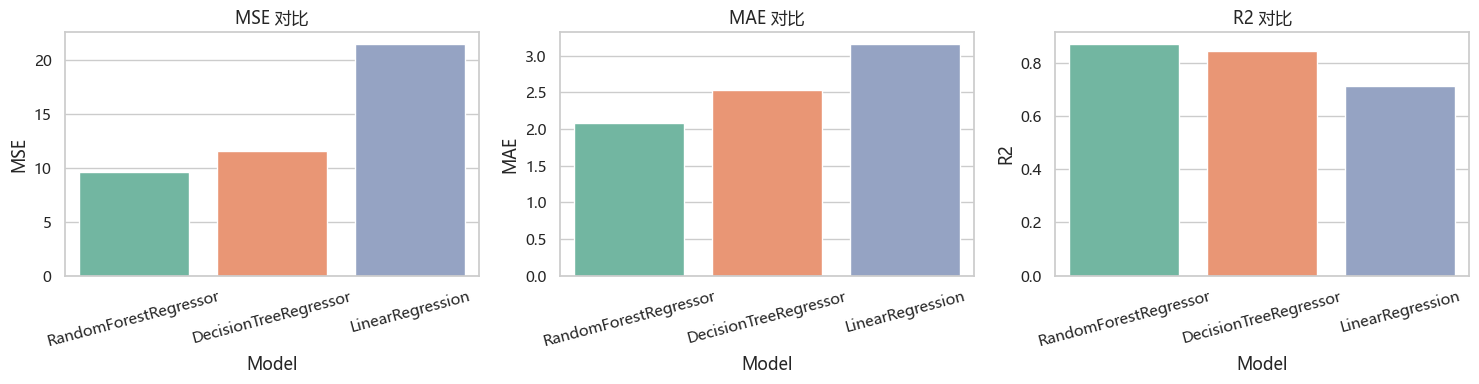

In [6]:
# 分别把 MSE、MAE、R2 画成三个子图，方便比较
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ["MSE", "MAE", "R2"]

for ax, metric in zip(axes, metrics):
    sns.barplot(data=results_df, x="Model", y=metric, ax=ax, palette="Set2")
    ax.set_title(f"{metric} 对比")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 第 7 步：绘制“预测值 vs 真实值”散点图

这是回归实验里很常见的一种可视化方式。

理想情况是：

- 散点尽量贴近红色参考线 `y = x`；
- 偏离越小，说明预测值越接近真实值；
- 如果某个模型的点云更分散，说明它的预测误差通常更大。

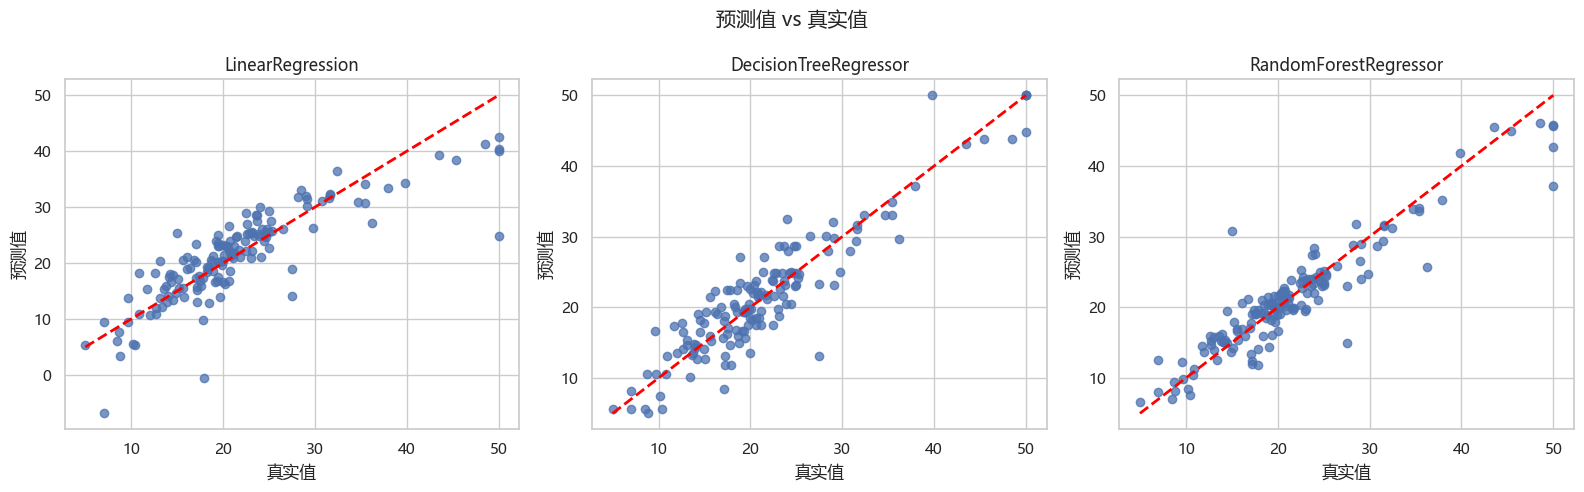

In [7]:
# 为每个模型各画一个“预测值 vs 真实值”散点图
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 参考线的范围取测试集真实值的最小值和最大值
y_min, y_max = float(np.min(y_test)), float(np.max(y_test))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    # 散点图中的每个点都代表一个测试样本
    ax.scatter(y_test, y_pred, alpha=0.75)

    # 红色虚线 y=x 表示“预测值完全等于真实值”的理想情况
    ax.plot([y_min, y_max], [y_min, y_max], color="red", linestyle="--", linewidth=2)

    ax.set_title(name)
    ax.set_xlabel("真实值")
    ax.set_ylabel("预测值")

plt.suptitle("预测值 vs 真实值")
plt.tight_layout()
plt.show()

## 实验结论参考写法

报告分析时可以重点写下面几点：

- 线性回归更适合捕捉整体线性关系，模型结构简单、解释性较强。
- 决策树回归能够学习非线性规律，但单棵树容易过拟合。
- 随机森林通过集成多棵树，通常在误差和稳定性上会优于单棵树。
- 如果某个模型的散点更贴近 `y=x` 参考线，说明该模型预测效果更好。